In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import kmodes
import umap
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt
from sklearn.preprocessing import PowerTransformer

In [17]:
data = pd.read_csv("aw_fb_data.csv", sep=",", index_col=0)
data.head(3)

,X1,age,gender,height,weight,steps,hear_rate,calories,distance,entropy_heart,entropy_setps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance,device,activity
1,1,20,1,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.0,19.531302,0.138520,1.0,0.089692,apple watch,Lying
2,2,20,1,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.0,19.453390,0.137967,1.0,0.102088,apple watch,Lying
3,3,20,1,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.0,19.540825,0.138587,1.0,0.115287,apple watch,Lying


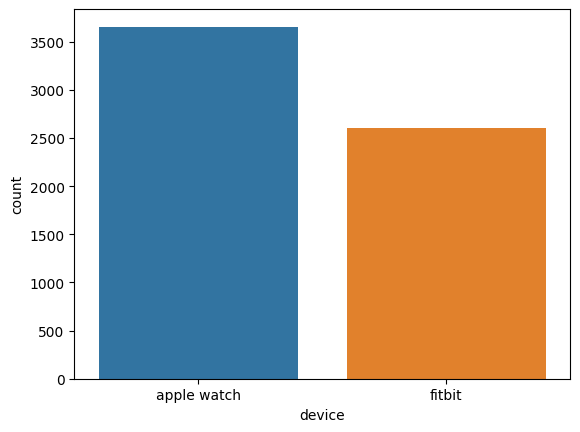

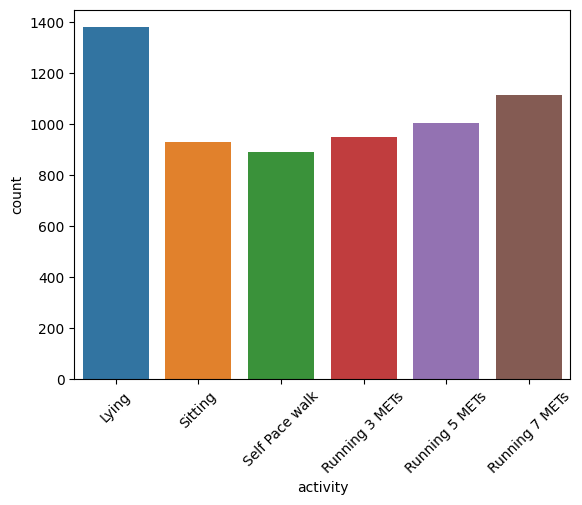

In [18]:
# data[["device", "activity"]]
sns.countplot(data=data, x="device")
plt.show()
sns.countplot(data=data, x="activity")
plt.xticks(rotation=45)
plt.show()

In [19]:
data.drop(columns=["X1"], inplace=True)

In [20]:
data.describe()

,age,gender,height,weight,steps,hear_rate,calories,distance,entropy_heart,entropy_setps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance
count,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000,6264.000000
mean,29.158525,0.476533,169.709052,69.614464,109.562268,86.142331,19.471823,13.832555,6.030314,5.739984,65.869938,0.306447,20.272393,0.155479,8.110854,590.035239
std,8.908978,0.499489,10.324698,13.451878,222.797908,28.648385,27.309765,45.941437,0.765574,1.256348,21.203017,0.775418,28.388116,0.210927,12.535080,4063.838530
min,18.000000,0.000000,143.000000,43.000000,1.000000,2.222222,0.056269,0.000440,0.000000,0.000000,3.000000,-1.000000,-76.000000,-2.714286,0.000000,0.000690
25%,23.000000,0.000000,160.000000,60.000000,5.159534,75.598079,0.735875,0.019135,6.108524,5.909440,58.134333,-0.467303,1.148883,0.009819,0.264722,0.659260
50%,28.000000,0.000000,168.000000,68.000000,10.092029,77.267680,4.000000,0.181719,6.189825,6.157197,75.000000,0.665829,9.820254,0.079529,2.893503,13.368619
75%,33.000000,1.000000,180.000000,77.300000,105.847222,95.669118,20.500000,15.697188,6.247928,6.247928,76.138701,1.000000,27.077336,0.211868,9.679672,93.728562
max,56.000000,1.000000,191.000000,115.000000,1714.000000,194.333333,97.500000,335.000000,6.475733,6.475733,155.000000,1.000000,156.319444,1.297980,74.457929,51520.000000


In [23]:
# std_scaler = StandardScaler()
# std_scaler.fit(f_data)
# x_data_norm = std_scaler.transform(f_data)

# pd.DataFrame(x_data_norm).describe()
numerical.shape

(6264, 16)

In [28]:
#Preprocessing numerical
numerical = data.select_dtypes(exclude='object')

for c in numerical.columns:
    pt = PowerTransformer()
    numerical.loc[:, c] = pt.fit_transform(np.array(numerical[c]).reshape(-1, 1))
    
##preprocessing categorical
categorical = data.select_dtypes(include='object')
categorical = pd.get_dummies(categorical)

#Percentage of columns which are categorical is used as weight parameter in embeddings later
categorical_weight = len(data.select_dtypes(include='object').columns) / data.shape[1]

#Embedding numerical & categorical
print(numerical)
fit1 = umap.UMAP.fit(X=numerical)
fit2 = umap.UMAP.fit(X=categorical)

           age    gender    height    weight     steps  hear_rate  calories  \
1    -1.310519  1.048090 -0.210208 -0.228966 -0.222200  -0.214197 -1.179948   
2    -1.310519  1.048090 -0.210208 -0.228966 -0.181569  -0.216996 -0.242039   
3    -1.310519  1.048090 -0.210208 -0.228966 -0.143660  -0.213854  0.367221   
4    -1.310519  1.048090 -0.210208 -0.228966 -0.108160  -0.210714  0.406204   
5    -1.310519  1.048090 -0.210208 -0.228966 -0.074804  -0.207574  0.442545   
...        ...       ...       ...       ...       ...        ...       ...   
6260  1.619492 -0.954117 -1.173674  0.230389 -1.760492  -1.970066  0.795090   
6261  1.619492 -0.954117 -1.173674  0.230389 -1.760492  -1.970066  0.795090   
6262  1.619492 -0.954117 -1.173674  0.230389 -1.760492  -1.970066  0.795090   
6263  1.619492 -0.954117 -1.173674  0.230389 -1.760492  -1.970066  0.795090   
6264  1.619492 -0.954117 -1.173674  0.230389 -1.760492  -1.970066  0.795090   

      distance  entropy_heart  entropy_setps  resti

C:\Users\alejo\AppData\Local\Temp\ipykernel_13980\2041197035.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.31051891 -1.31051891 -1.31051891 ...  1.61949242  1.61949242
  1.61949242]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  numerical.loc[:, c] = pt.fit_transform(np.array(numerical[c]).reshape(-1, 1))
C:\Users\alejo\AppData\Local\Temp\ipykernel_13980\2041197035.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.04808991  1.04808991  1.04808991 ... -0.95411662 -0.95411662
 -0.95411662]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  numerical.loc[:, c] = pt.fit_transform(np.array(numerical[c]).reshape(-1, 1))


TypeError: UMAP.fit() missing 1 required positional argument: 'self'

In [ ]:
intersection = umap.umap_.general_simplicial_set_intersection(fit1.graph_, fit2.graph_, weight=categorical_weight)
intersection = umap.umap_.reset_local_connectivity(intersection)
embedding = umap.umap_.simplicial_set_embedding(fit1._raw_data, intersection, fit1.n_components, 
                                                fit1._initial_alpha, fit1._a, fit1._b, 
                                                fit1.repulsion_strength, fit1.negative_sample_rate, 
                                                200, 'random', np.random, fit1.metric, 
                                                fit1._metric_kwds, False)

plt.figure(figsize=(20, 10))
plt.scatter(*embedding.T, s=2, cmap='Spectral', alpha=1.0)
plt.show()



AttributeError: 'int' object has no attribute 'randint'

In [ ]:
# Identify IQR-based outliers for every numerical variable
import numpy as np

numeric_cols = data.select_dtypes(include=[np.number]).columns

outliers_dict: dict[str, list[int]] = {}
outliers_mask = pd.DataFrame(False, index=data.index, columns=numeric_cols)

for col in numeric_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[col] < lower) | (data[col] > upper)
    outliers_mask[col] = mask
    outliers_dict[col] = data.index[mask].tolist()

# Summary: number of outliers per column (descending)
outliers_counts = outliers_mask.sum().sort_values(ascending=False)
display(outliers_counts.to_frame("num_outliers"))

# Optional: view the rows that are outliers in at least one numeric column
outlier_rows = data[outliers_mask.any(axis=1)]
outlier_rows.head()


,num_outliers
calories,1149
hear_rate,1050
steps,814
entropy_setps,641
entropy_heart,639
sd_norm_heart,636
resting_heart,634
intensity_karvonen,520
steps_times_distance,476
norm_heart,474


,age,gender,height,weight,steps,hear_rate,calories,distance,entropy_heart,entropy_setps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance,device,activity
70,20,1,168.0,65.4,284.333333,73.000000,17.9906,0.187767,6.221612,6.116349,59.0,0.151596,14.000000,0.099291,9.324012,53.388322,apple watch,Running 7 METs
71,20,1,168.0,65.4,351.916667,76.000000,17.9934,0.232398,6.221612,6.116349,59.0,-0.156528,17.000000,0.120567,8.146451,81.784847,apple watch,Running 7 METs
72,20,1,168.0,65.4,419.500000,80.000000,17.9962,0.277030,6.221612,6.116349,59.0,1.000000,21.000000,0.148936,7.528704,116.214085,apple watch,Running 7 METs
152,24,0,165.0,43.0,338.490909,80.636364,0.0610,0.032615,6.135030,6.189825,76.5,-0.387936,4.136364,0.034614,2.586121,11.039837,apple watch,Lying
153,24,0,165.0,43.0,420.420779,74.769231,0.0610,0.038687,6.135030,6.189825,76.5,-0.367209,-1.730769,-0.014483,2.560843,16.264765,apple watch,Lying
